# Combined Case Schematics

2x3 panel figure combining the reservoir domain schematic of every case.
- Row 1 (a-c): domain/geometry -- Cases 1 and 4, Case 3, Case 5
- Row 2 (d-f): Case 2 permeability -- fine mesh, coarse mesh, ln(k) distribution


In [1]:
# =============================================================================
#  0 · Environment and Configuration
#  (rcParams are identical to every individual case notebook)
# =============================================================================

import numpy as np
import h5py, json
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as patches
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from pathlib import Path

from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.rcParams.update({
    # LaTeX font rendering
    'text.usetex'          : True,
    'font.family'          : 'serif',
    'font.serif'           : ['Computer Modern Roman'],
    'text.latex.preamble'  : r'\usepackage{amsmath} \usepackage{amssymb} \usepackage{bm}',
    # Font sizes
    'font.size'            : 13,
    'axes.labelsize'       : 13,
    'axes.titlesize'       : 13,
    'legend.fontsize'      : 13,
    'xtick.labelsize'      : 13,
    'ytick.labelsize'      : 13,
    # Ticks
    'xtick.direction'      : 'out',   'ytick.direction'      : 'out',
    'xtick.top'            : True,    'ytick.right'          : True,
    'xtick.minor.visible'  : False,   'ytick.minor.visible'  : False,
    # Lines / spines
    'axes.linewidth'       : 1,       'lines.linewidth'      : 1.5,
    'lines.markersize'     : 6,
    # Grid (off)
    'axes.grid'            : False,   'grid.alpha'           : 0.20,
    'grid.linestyle'       : '--',    'grid.linewidth'       : 0.5,
    # Resolution
    'figure.dpi'           : 150,     'savefig.dpi'          : 600,
    'savefig.bbox'         : 'tight',
    # Legend
    'legend.frameon'       : True,    'legend.framealpha'    : 1.0,
    'legend.edgecolor'     : 'black', 'legend.fancybox'      : False,
    'legend.handlelength'  : 1.5,     'legend.labelspacing'  : 0.4,
    'legend.handletextpad' : 0.5,     'legend.borderaxespad' : 0.5,
    # Tick padding
    'xtick.major.pad'      : 5.0,     'ytick.major.pad'      : 5.0,
})

# Colour palette — identical to all individual notebooks
C2, C3, C4 = '#0d6e56', '#9b2a1a', '#b07318'
C1 = '#2c3e50'    # Matrix
LF_C = '#e74c3c'  # Fracture                         # Case 3: fracture colour
WC   = ['#1a5e9e', '#9b2a1a', '#0d6e56']  # Case 5: W1 blue · W2 red · W3 green

print('Environment ready.')

Environment ready.


In [2]:
# =============================================================================
#  1 · Paths and save helper
#  New notebook lives in the SAME folder as the individual case notebooks.
#  All DATA paths are unchanged.  Output goes to PROJECT/figures/combined/.
# =============================================================================

PROJECT   = Path('..')
DATA_ROOT = PROJECT / 'data' / '01_synthetic'

DATA_C1     = DATA_ROOT / 'case1_homogeneous'
DATA_C2_APX = DATA_ROOT / 'case2_heterogeneous'   # coarse 50x50
DATA_C2_GT  = DATA_ROOT / 'case2_finemesh'         # fine  200x200
DATA_C3     = DATA_ROOT / 'case3_fractured'
DATA_C4     = DATA_ROOT / 'case4_variable_rate'
DATA_C6     = DATA_ROOT / 'case5_multiwell'

FIGS_OUT = PROJECT / 'figures' / 'combined'
FIGS_OUT.mkdir(parents=True, exist_ok=True)

def sf(name):
    plt.savefig(FIGS_OUT / name, dpi=300, bbox_inches='tight')
    print(f'  Saved  ->  {FIGS_OUT / name}')

print(f'Output directory : {FIGS_OUT}')

Output directory : ..\figures\combined


In [3]:
# =============================================================================
#  2 · Load — Cases 1 & 4  (identical homogeneous domain)
# =============================================================================

ft_to_km = 0.0003048

# Case 1
with open(DATA_C1 / 'params.json') as f:
    P_C1 = json.load(f)

nx_c1  = int(P_C1['nx']);   ny_c1  = int(P_C1['ny'])
dx_km  = P_C1['dx_ft'] * ft_to_km          # cell side in km (dx = dy)
Lx_c1  = nx_c1 * dx_km;    Ly_c1  = ny_c1 * dx_km
x_w_c1 = Lx_c1 / 2;        y_w_c1 = Ly_c1 / 2
q_c1   = P_C1['q_STBd']                    # single constant rate

# Case 4
with open(DATA_C4 / 'params.json') as f:
    P_C4 = json.load(f)

q1_c4 = P_C4['q1_STBd']
q2_c4 = P_C4['q2_STBd']
q3_c4 = P_C4['q3_STBd']

print(f'C1/C4 domain : {Lx_c1:.2f} x {Ly_c1:.2f} km  |  well @ ({x_w_c1:.2f}, {y_w_c1:.2f}) km')
print(f'Case 1  q = {q_c1:.0f} STB/day  (constant)')
print(f'Case 4  q = {q1_c4:.0f} -> {q2_c4:.0f} -> {q3_c4:.0f} -> 0 STB/day  (variable)')

C1/C4 domain : 1.50 x 1.50 km  |  well @ (0.75, 0.75) km
Case 1  q = 800 STB/day  (constant)
Case 4  q = 800 -> 400 -> 1200 -> 0 STB/day  (variable)


In [4]:
# =============================================================================
#  3 · Load — Case 2  (coarse approximation + fine ground truth)
# =============================================================================

# ── Coarse (50 x 50) ─────────────────────────────────────────────────────────
with open(DATA_C2_APX / 'params.json') as f:
    P_C2_APX = json.load(f)

with h5py.File(DATA_C2_APX / 'rock_field.mat', 'r') as f:
    perm_apx = np.array(f['perm_mD']).flatten()

nx_apx = int(P_C2_APX['nx']);  ny_apx = int(P_C2_APX['ny'])
k_apx  = perm_apx.reshape(ny_apx, nx_apx)

# ── Fine  (200 x 200) ────────────────────────────────────────────────────────
with open(DATA_C2_GT / 'params.json') as f:
    P_C2_GT = json.load(f)

with h5py.File(DATA_C2_GT / 'rock_field.mat', 'r') as f:
    perm_gt = np.array(f['perm_mD']).flatten()

nx_gt = int(P_C2_GT['nx']);    ny_gt = int(P_C2_GT['ny'])
k_gt  = perm_gt.reshape(ny_gt, nx_gt)

# Shared log-colour limits for panels (d) and (e)
vmin_k = np.log10(min(perm_gt.min(), perm_apx.min()))
vmax_k = np.log10(max(perm_gt.max(), perm_apx.max()))

# ln(k) statistics — coarse field, consistent with case2_pod_dmd_analysis
mu_lnk  = np.mean(np.log(perm_apx))
sig_lnk = np.std (np.log(perm_apx))

print(f'C2 coarse : {nx_apx}x{ny_apx}  k in [{perm_apx.min():.1f}, {perm_apx.max():.0f}] mD')
print(f'C2 fine   : {nx_gt}x{ny_gt}  k in [{perm_gt.min():.1f},  {perm_gt.max():.0f}] mD')
print(f'log10(k): vmin = {vmin_k:.3f}   vmax = {vmax_k:.3f}')
print(f'ln(k)  :  mu   = {mu_lnk:.3f}   sigma = {sig_lnk:.3f}')

C2 coarse : 50x50  k in [1.0, 2000] mD
C2 fine   : 200x200  k in [1.0,  2000] mD
log10(k): vmin = -0.000   vmax = 3.301
ln(k)  :  mu   = 3.065   sigma = 1.886


In [5]:
# =============================================================================
#  4 · Load — Case 3  (hydraulically fractured)
# =============================================================================

with open(DATA_C3 / 'params.json') as f:
    P_C3 = json.load(f)

with h5py.File(DATA_C3 / 'rock_field.mat', 'r') as f:
    perm_c3 = np.array(f['perm_mD']).flatten()

with h5py.File(DATA_C3 / 'grid_field.mat', 'r') as f:
    _c = np.array(f['centroids_ft'])
    centroids_ft = _c.T if _c.shape[0] == 2 else _c

with h5py.File(DATA_C3 / 'frac_cells.mat', 'r') as f:
    frac_cells_py = np.array(f['frac_cells']).flatten().astype(int) - 1

nx_c3     = int(P_C3['nx']);   ny_c3     = int(P_C3['ny'])
Lx_c3_km  = P_C3['Lx_ft'] * ft_to_km
Ly_c3_km  = P_C3['Ly_ft'] * ft_to_km
k_m_c3    = P_C3['k_matrix_mD']
k_f_c3    = P_C3['k_fracture_mD']
xf_m_c3   = P_C3['xf_m']

# Fracture column: grid column whose x-centroid is closest to domain centre
x_row        = centroids_ft[:nx_c3, 0]
frac_col_py  = int(np.argmin(np.abs(x_row - P_C3['Lx_ft'] / 2)))
frac_row_min = int(frac_cells_py.min() // nx_c3)
frac_row_max = int(frac_cells_py.max() // nx_c3)

# Binary field: 0 = matrix, 1 = fracture
binary_c3 = np.zeros((ny_c3, nx_c3))
binary_c3[frac_row_min:frac_row_max + 1, frac_col_py] = 1

# Physical km coordinates of fracture / well for markers and text
x_frac_km    = (frac_col_py + 0.5) / nx_c3 * Lx_c3_km
y_mid_km_c3  = Ly_c3_km / 2.0
y_fmin_km_c3 = (frac_row_min       / ny_c3) * Ly_c3_km
y_fmax_km_c3 = ((frac_row_max + 1) / ny_c3) * Ly_c3_km

print(f'C3 domain  : {Lx_c3_km:.0f} x {Ly_c3_km:.0f} km')
print(f'k_m = {k_m_c3:.0f} mD   k_f = {k_f_c3:.0f} mD   x_f = {xf_m_c3:.0f} m')
print(f'Fracture   : col {frac_col_py}  rows {frac_row_min}-{frac_row_max}')

C3 domain  : 6 x 6 km
k_m = 5 mD   k_f = 100000 mD   x_f = 400 m
Fracture   : col 50  rows 52-67


In [6]:
# =============================================================================
#  5 · Load — Case 5  (three-well staggered startup)
# =============================================================================

with open(DATA_C6 / 'params.json') as f:
    P_C6 = json.load(f)

# Physical dimensions — values match case5_multiwell.ipynb
nx_c6   = 100;   ny_c6   = 100
dx_m_c6 = 100;   dy_m_c6 = 60           # metres per cell
Lx_c6   = (nx_c6 * dx_m_c6) / 1000.0   # 10 km
Ly_c6   = (ny_c6 * dy_m_c6) / 1000.0   #  6 km

# Well positions (MATLAB ix = 40, 50, 60; iy = 50 -> Python km coords)
x_w1_c6 = (40 - 0.5) * dx_m_c6 / 1000.0
x_w2_c6 = (50 - 0.5) * dx_m_c6 / 1000.0
x_w3_c6 = (60 - 0.5) * dx_m_c6 / 1000.0
y_w_c6  = (50 - 0.5) * dy_m_c6 / 1000.0

print(f'C6 domain : {Lx_c6:.0f} x {Ly_c6:.0f} km')
print(f'PW1 @ ({x_w1_c6:.2f}, {y_w_c6:.2f}) km')
print(f'PW2 @ ({x_w2_c6:.2f}, {y_w_c6:.2f}) km')
print(f'PW3 @ ({x_w3_c6:.2f}, {y_w_c6:.2f}) km')
print('\nAll data loaded successfully.')

C6 domain : 10 x 6 km
PW1 @ (3.95, 2.97) km
PW2 @ (4.95, 2.97) km
PW3 @ (5.95, 2.97) km

All data loaded successfully.


  Saved  ->  ..\figures\combined\ch4_1_reservoirs_geo.pdf


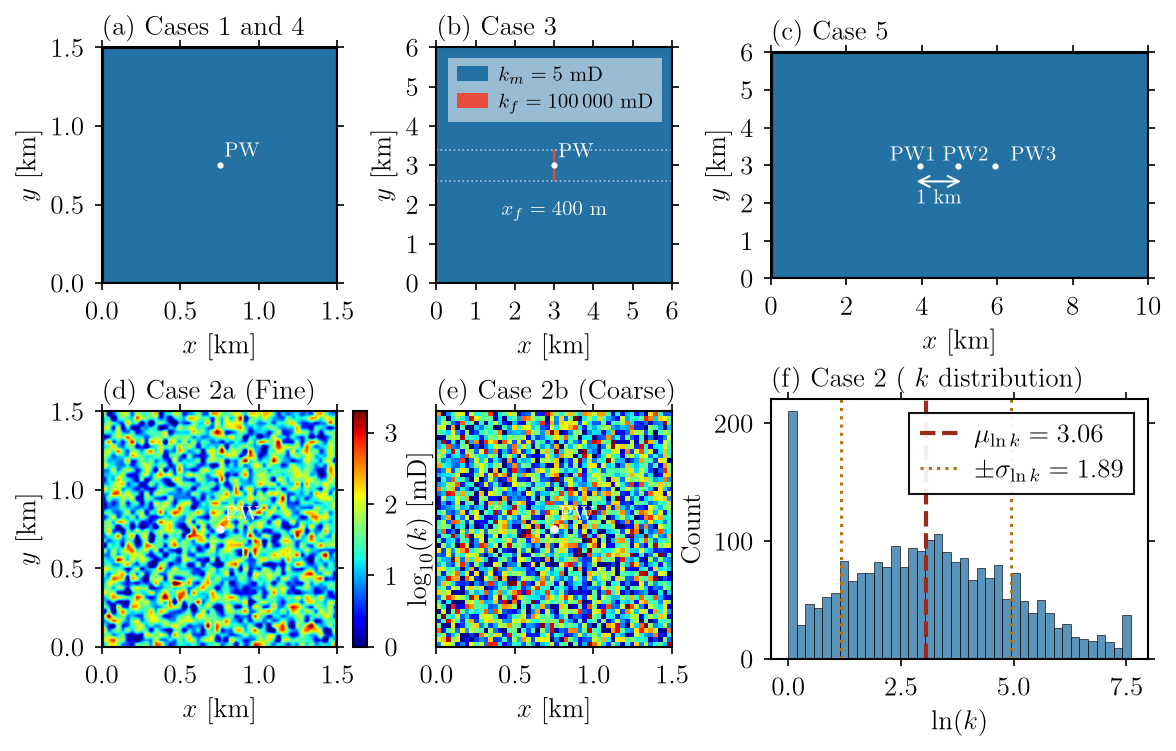

In [7]:
# =============================================================================
#  6 · Combined schematic figure — 2 rows x 3 columns
#  Strict Grid Alignment Version with Colorbar shifted to Panel (d)
# =============================================================================

# Updated high-contrast palette definitions
C1 = '#2471a3'   # Matrix: Deep, professional Slate Blue-Gray
LF_C = '#e74c3c'   # Fracture: High-intensity Crimson Red
cmap_frac = ListedColormap([C1, LF_C])   # Case 3: matrix (C1) | fracture (LF_C)

# Single uniform grid to guarantee perfect column-wise alignment
fig = plt.figure(figsize=(9, 5.4))
gs = fig.add_gridspec(2, 3, width_ratios=[1, 1, 1.6], height_ratios=[1, 1], 
                      wspace=0.35, hspace=0.4)

axes = np.empty((2, 3), dtype=object)
for i in range(2):
    for j in range(3):
        axes[i, j] = fig.add_subplot(gs[i, j])

# =============================================================================
# (a)  Cases 1 and 4 — Homogeneous reservoir domain
# =============================================================================
ax = axes[0, 0]

ax.add_patch(patches.Rectangle(
    (0, 0), Lx_c1, Ly_c1, facecolor='#2471a3', zorder=1)) # Color updated to match C1
ax.add_patch(patches.Rectangle(
    (0, 0), Lx_c1, Ly_c1, fill=False, edgecolor='black', lw=1.5, zorder=10))

ax.plot(x_w_c1, y_w_c1, 'o', ms=3,
        markeredgecolor='none', markerfacecolor='white', lw=0, zorder=10)
ax.text(x_w_c1 + 0.03, y_w_c1 + 0.03, 'PW',
        color='white', fontsize=10, ha='left', va='bottom',
        bbox=dict(facecolor='none', edgecolor='none', alpha=0.85, pad=1.5),
        zorder=10)

ax.set_aspect('equal', adjustable='box')
ax.set_xlim(0, Lx_c1);   ax.set_ylim(0, Ly_c1)
ax.xaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax.set_xlabel(r'$x \ [\mathrm{km}]$')
ax.set_ylabel(r'$y \ [\mathrm{km}]$')
ax.set_title('(a) Cases 1 and 4', loc='left', fontweight='normal')

# =============================================================================
# (b)  Case 3 — Hydraulically fractured domain
# =============================================================================
ax = axes[0, 1]

ax.imshow(binary_c3, origin='lower', cmap=cmap_frac,
          aspect='equal', extent=[0, Lx_c3_km, 0, Ly_c3_km],
          vmin=0, vmax=1)

ax.axhline(y_fmin_km_c3, color='white', lw=0.8, ls=':', alpha=0.6)
ax.axhline(y_fmax_km_c3, color='white', lw=0.8, ls=':', alpha=0.6)

ax.plot(x_frac_km, y_mid_km_c3, 'o', ms=3, mew=2.5,
        markerfacecolor='white', markeredgecolor='none', zorder=10)
ax.text(x_frac_km + 0.10, y_mid_km_c3 + 0.10, 'PW',
        color='white', fontsize=10, ha='left', va='bottom', zorder=10)

ax.text(3.0, 2.1, r'$x_f = 400\ \mathrm{m}$', color='white', fontsize=10,
        ha='center', va='top', fontweight='bold', zorder=12)

ax.legend(handles=[
    Patch(facecolor=C1,   label=fr'$k_m = {k_m_c3:.0f}$ mD'),
    Patch(facecolor=LF_C, label=fr'$k_f = {int(k_f_c3/1000):,}\,000$ mD'),
], loc='upper right', framealpha=0.53, fontsize=10, edgecolor='none')

ax.set_aspect('equal', adjustable='box')
ax.set_xlim(0, Lx_c3_km);   ax.set_ylim(0, Ly_c3_km)
ax.xaxis.set_major_locator(ticker.MultipleLocator(1.0))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
ax.tick_params(which='both', direction='out', top=True, right=True)
ax.set_xlabel(r'$x \ [\mathrm{km}]$')
ax.set_ylabel(r'$y \ [\mathrm{km}]$')
ax.set_title('(b) Case 3', loc='left', fontweight='normal')

# =============================================================================
# (c)  Case 5 — Three-well staggered-startup domain
# =============================================================================
ax = axes[0, 2]

ax.add_patch(patches.Rectangle(
    (0, 0), Lx_c6, Ly_c6, facecolor='#2471a3', zorder=1)) # Color updated to match C1
ax.add_patch(patches.Rectangle(
    (0, 0), Lx_c6, Ly_c6, fill=False, edgecolor='black', lw=1.5, zorder=10))

lbl_bbox_c6 = dict(facecolor='none', edgecolor='none', alpha=0.85, pad=1.5)
x_offsets = [-0.8, -0.4, 0.4]
y_offsets = [0.05, 0.05, 0.05] # Pushes PW2 higher, and PW3 highest

# Zip the offsets together with your coordinates and labels
for xi, lbl, dx, dy in zip([x_w1_c6, x_w2_c6, x_w3_c6], ['PW1', 'PW2', 'PW3'], x_offsets, y_offsets):
    
    # Plot the marker
    ax.plot(xi, y_w_c6, 'o', ms=3, markeredgecolor='none', markerfacecolor='white', lw=0, zorder=10)
    
    # Place text using the custom dx and dy offsets
    ax.text(xi + dx, y_w_c6 + dy, lbl,
            color='white', fontsize=10, ha='left', va='bottom',
            bbox=lbl_bbox_c6, zorder=10)


# ─── NEW: Add Dimension Line and "1 km apart" text ───
# Draw a double-headed arrow between PW1 and PW2 just below the wells
ax.annotate('', xy=(x_w1_c6-0.2, y_w_c6 - 0.4), xytext=(x_w2_c6+0.2, y_w_c6 - 0.4),
            arrowprops=dict(arrowstyle='<->', color='white', lw=1.0), zorder=10)

# Add the centered text below the arrow
ax.text((x_w1_c6 + x_w2_c6) / 2, y_w_c6 - 0.6, '1 km', 
        color='white', fontsize=10, ha='center', va='top', zorder=10)

# adjustable='box' forces the 10x6 layout to comfortably shape inside the aligned column boundary
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(0, Lx_c6);   ax.set_ylim(0, Ly_c6)
ax.xaxis.set_major_locator(ticker.MultipleLocator(2.0))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1.0))
ax.set_xlabel(r'$x \ [\mathrm{km}]$')
ax.set_ylabel(r'$y \ [\mathrm{km}]$')
ax.set_title('(c) Case 5', loc='left', fontweight='normal')




# =============================================================================
# (d)  Case 2 (Fine mesh) — log10(k) with Appended Colorbar
# =============================================================================
ax = axes[1, 0]

im_fine = ax.imshow(
    np.log10(k_gt), origin='lower', cmap='jet',
    vmin=vmin_k, vmax=vmax_k, aspect='equal',
    extent=[0, 1.5, 0, 1.5])

ax.plot(0.75, 0.75, 'o', ms=3, color='white', zorder=15)
ax.text(0.78, 0.78, 'PW', color='white', fontsize=10,
        ha='left', va='bottom', zorder=15)

ax.set_aspect('equal', adjustable='box')
ax.set_xlim(0, 1.5);   ax.set_ylim(0, 1.5)
ax.set_xticks([0.0, 0.5, 1.0, 1.5])
ax.set_yticks([0.0, 0.5, 1.0, 1.5])
ax.set_xlabel(r'$x$ [km]')
ax.set_ylabel(r'$y$ [km]')
ax.set_title('(d) Case 2a (Fine)', loc='left', fontweight='normal')

# =============================================================================
#  PLACING THE COLORBAR SEPARATELY IN THE MIDDLE BETWEEN (d) AND (e)
# =============================================================================
fig.canvas.draw()

pos_d = axes[1, 0].get_position()
pos_e = axes[1, 1].get_position()

cbar_width = 0.01   
middle_x = pos_d.x1 + (pos_e.x0 - pos_d.x1) / 2 - (cbar_width / 2) -0.02

cax = fig.add_axes([middle_x, pos_d.y0, cbar_width, pos_d.height])

cbar = fig.colorbar(im_fine, cax=cax) 
cbar.set_label(r'$\log_{10}(k)$ [mD]', fontsize=13)
cbar.ax.tick_params(labelsize=13)

# =============================================================================
# (e)  Case 2 (Coarse mesh) — log10(k)
# =============================================================================
ax = axes[1, 1]

im_coarse = ax.imshow(
    np.log10(k_apx), origin='lower', cmap='jet',
    vmin=vmin_k, vmax=vmax_k, aspect='equal',
    extent=[0, 1.5, 0, 1.5])

ax.plot(0.75, 0.75, 'o', ms=3, color='white', zorder=15)
ax.text(0.78, 0.78, 'PW', color='white', fontsize=10,
        ha='left', va='bottom', zorder=15)

ax.set_aspect('equal', adjustable='box')
ax.set_xlim(0, 1.5);   ax.set_ylim(0, 1.5)
ax.set_xticks([0.0, 0.5, 1.0, 1.5])
ax.set_yticks([])
ax.set_xlabel(r'$x$ [km]')
ax.set_title('(e) Case 2b (Coarse)', loc='left', fontweight='normal')

# =============================================================================
# (f)  Case 2 (Frequency distribution)
# =============================================================================
ax = axes[1, 2]

ax.hist(np.log(perm_apx), bins=40,
        color=C1, alpha=0.75, edgecolor='k', lw=0.4)
ax.axvline(mu_lnk, color=C3, lw=2.0, ls='--',
           label=fr'$\mu_{{\ln k}} = {mu_lnk:.2f}$')
ax.axvline(mu_lnk - sig_lnk, color=C4, lw=1.5, ls=':',
           label=fr'$\pm\sigma_{{\ln k}} = {sig_lnk:.2f}$')
ax.axvline(mu_lnk + sig_lnk, color=C4, lw=1.5, ls=':')

ax.set_xlabel(r'$\ln(k)$')
ax.set_ylabel('Count')
ax.set_title('(f) Case 2 ( $k$ distribution)', loc='left', fontweight='normal')
ax.legend(fontsize=13, framealpha=0.93)

# =============================================================================
# Save
# =============================================================================
sf('ch4_1_reservoirs_geo.pdf') 
plt.show()